# Primary Survey Data Analysis: Automated vs Manual Data Processing

## Overview
This notebook implements the primary-data hypothesis testing component described in Section 3.9
of the dissertation. An online questionnaire was administered to data engineering, IT, and
operational/financial data-processing professionals, who were grouped according to whether their
organisation primarily relies on an automated cloud-based data pipeline or on manual/legacy
methods. Twelve five-point Likert-scale items measured perceived data accuracy, time spent on
manual reconciliation, frequency of data quality issues, and confidence in reporting outcomes.

Consistent with the ordinal nature of Likert-scale data and the unequal, non-randomly assigned
group sizes discussed in Sections 3.5 and 3.9, a Mann-Whitney U test is used to test the
following hypotheses for each item:

H0: There is no statistically significant difference between the automated-pipeline group and
the manual/legacy group.

H1: Professionals using automated cloud-based data pipelines report significantly better outcomes
than those using manual or legacy data-processing methods.

In [0]:
%pip install openpyxl

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Step 1: Data Ingestion

The raw questionnaire export is first located and inspected within the Volume prior to loading,
consistent with the inspect-before-load approach adopted in the Bronze layer. Given the limited
scale of the primary dataset relative to the secondary CMS dataset, pandas is used for this
notebook rather than Spark, which is appropriate for survey-scale data of this size.

In [0]:
display(dbutils.fs.ls("/Volumes/adb_pharma_analytics/gold/primary_data/"))

path,name,size,modificationTime
dbfs:/Volumes/adb_pharma_analytics/gold/primary_data/Primary data.xlsx,Primary data.xlsx,13976,1787952426000


In [0]:
import pandas as pd

file_path = "/Volumes/adb_pharma_analytics/gold/primary_data/Primary data.xlsx"
df = pd.read_excel(file_path)
cols = df.columns.tolist()

print(f"Total responses loaded: {len(df)}")
print(f"Total columns: {len(cols)}")
display(df.head(3))

Total responses loaded: 65
Total columns: 15


I confirm that I am 18 years or older and voluntarily agree to participate in this research.,"Do you currently work, or have you recently worked (including internships), in a role involving data engineering, IT systems, or operational/financial data processing?","Does your organisation primarily rely on an automated cloud-based data pipeline (e.g., Azure, AWS, Databricks, Snowflake) for processing operational/financial data, or does your team mainly use manual/legacy methods (e.g., Excel, manual reconciliation)?",I am confident that the data processed by my team is accurate.,Errors are rarely found in the reports my team produces.,The data I work with is generally reliable without needing extensive double-checking.,I spend a significant amount of time manually checking or reconciling data.,"Manual data-checking is a routine, time-consuming part of my role.",I rarely need to manually correct or adjust data before using it.,"Data quality issues (missing values, duplicates, inconsistent formats) are common in the data I work with.",I rarely encounter data quality problems in my day-to-day work.,My team frequently has to deal with incomplete or messy data.,I am confident in the reports and dashboards I use for decision-making.,"I can quickly access up-to-date, reliable data when I need it.",I trust the accuracy of the numbers shown in my team's reports.
I Agree,Yes,Automated pipeline,5,5,3,3,1,3,5,3,5,5,5,5
I Agree,Yes,Automated pipeline,5,5,2,1,1,3,5,1,5,5,5,5
I Agree,Yes,Automated pipeline,5,5,5,3,1,3,3,3,3,5,5,5


## Step 2: Screening Validation and Group Composition

The two screening questions (informed consent and professional eligibility) are validated to
confirm that every retained response satisfies the inclusion criteria set out in Section 3.6.
Group membership counts are then established for the subsequent analysis.

In [0]:
consent_col, role_col, group_col = cols[0], cols[1], cols[2]

print(f"Consent check -> {df[consent_col].value_counts().to_dict()}")
print(f"Role check    -> {df[role_col].value_counts().to_dict()}")
print()
print("Group membership:")
print(df[group_col].value_counts())

df = df.rename(columns={group_col: "Group"})
auto = df[df["Group"] == "Automated pipeline"]
manual = df[df["Group"] == "Manual or legacy methods"]

print()
print(f"n (Automated pipeline) = {len(auto)}")
print(f"n (Manual/legacy)      = {len(manual)}")
print(f"n (Total)               = {len(df)}")

Consent check -> {'I Agree': 65}
Role check    -> {'Yes': 65}

Group membership:
Does your organisation primarily rely on an automated cloud-based data pipeline (e.g., Azure, AWS, Databricks, Snowflake) for processing operational/financial data, or does your team mainly use manual/legacy methods (e.g., Excel, manual reconciliation)?  
Automated pipeline          43
Manual or legacy methods    22
Name: count, dtype: int64

n (Automated pipeline) = 43
n (Manual/legacy)      = 22
n (Total)               = 65


## Step 3: Descriptive Statistics by Group

Mean and standard deviation are computed for each of the twelve Likert items, split by group,
providing the baseline distributional picture prior to formal hypothesis testing.

In [0]:
item_map = {
    cols[3]:  "Confident that team data is accurate",
    cols[4]:  "Errors are rarely found in reports",
    cols[5]:  "Data is reliable without extensive double-checking",
    cols[6]:  "Spend significant time on manual reconciliation",
    cols[7]:  "Manual data-checking is a routine part of the role",
    cols[8]:  "Rarely need to manually correct or adjust data",
    cols[9]:  "Data quality issues (missing/duplicate/inconsistent) are common",
    cols[10]: "Rarely encounter data quality problems",
    cols[11]: "Team frequently deals with incomplete or messy data",
    cols[12]: "Confident in reports/dashboards used for decisions",
    cols[13]: "Can quickly access up-to-date, reliable data",
    cols[14]: "Trust the accuracy of numbers in team reports",
}
item_cols = list(item_map.keys())

desc_rows = []
for c in item_cols:
    desc_rows.append({
        "Item": item_map[c],
        "Auto_Mean": round(auto[c].mean(), 2),
        "Auto_SD": round(auto[c].std(), 2),
        "Manual_Mean": round(manual[c].mean(), 2),
        "Manual_SD": round(manual[c].std(), 2),
    })
desc_df = pd.DataFrame(desc_rows)
pd.set_option("display.max_colwidth", 55)
print(desc_df.to_string(index=False))

                                                           Item  Auto_Mean  Auto_SD  Manual_Mean  Manual_SD
                           Confident that team data is accurate       5.00     0.00         4.95       0.21
                             Errors are rarely found in reports       4.86     0.35         4.77       0.43
             Data is reliable without extensive double-checking       3.70     0.89         3.00       0.82
                Spend significant time on manual reconciliation       1.88     0.85         4.91       0.29
             Manual data-checking is a routine part of the role       1.70     0.80         4.86       0.35
                 Rarely need to manually correct or adjust data       3.93     0.67         1.09       0.29
Data quality issues (missing/duplicate/inconsistent) are common       4.72     0.55         4.95       0.21
                         Rarely encounter data quality problems       2.86     0.94         1.14       0.35
            Team frequently 

## Step 4: Rationale for Non-Parametric Testing

Likert-scale responses are ordinal rather than interval data. A Shapiro-Wilk normality test is
applied to each item to formally confirm that the parametric assumption of normality cannot be
safely assumed, thereby justifying the non-parametric Mann-Whitney U test specified in Section
3.9.

In [0]:
from scipy.stats import shapiro

normality_rows = []
for c in item_cols:
    combined = df[c].dropna()
    stat, p = shapiro(combined)
    normality_rows.append({"Item": item_map[c], "Shapiro_W": round(stat, 3), "p_value": round(p, 4),
                            "Normal_at_0.05": "Yes" if p > 0.05 else "No"})
norm_df = pd.DataFrame(normality_rows)
print(norm_df.to_string(index=False))
print()
non_normal_count = (norm_df["Normal_at_0.05"] == "No").sum()
print(f"{non_normal_count} of {len(norm_df)} items depart significantly from normality (p < 0.05),")
print("supporting the use of the Mann-Whitney U test rather than a parametric alternative.")

                                                           Item  Shapiro_W  p_value Normal_at_0.05
                           Confident that team data is accurate      0.104      0.0             No
                             Errors are rarely found in reports      0.453      0.0             No
             Data is reliable without extensive double-checking      0.878      0.0             No
                Spend significant time on manual reconciliation      0.806      0.0             No
             Manual data-checking is a routine part of the role      0.782      0.0             No
                 Rarely need to manually correct or adjust data      0.821      0.0             No
Data quality issues (missing/duplicate/inconsistent) are common      0.470      0.0             No
                         Rarely encounter data quality problems      0.854      0.0             No
            Team frequently deals with incomplete or messy data      0.470      0.0             No
          

/databricks/python/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


## Step 5: Mann-Whitney U Test per Item

Each of the twelve items is tested independently at a two-tailed significance level of alpha =
0.05, consistent with Section 3.9.

In [0]:
from scipy.stats import mannwhitneyu

mwu_rows = []
for c in item_cols:
    a = auto[c].dropna()
    m = manual[c].dropna()
    stat, p = mannwhitneyu(a, m, alternative="two-sided")
    mwu_rows.append({
        "Item": item_map[c],
        "U": stat,
        "p_value": round(p, 4),
        "Significant (p<0.05)": "Yes" if p < 0.05 else "No",
    })
mwu_df = pd.DataFrame(mwu_rows)
print(mwu_df.to_string(index=False))
print()
sig_count = (mwu_df["Significant (p<0.05)"] == "Yes").sum()
print(f"{sig_count} of {len(mwu_df)} items show a statistically significant difference between groups.")

                                                           Item     U  p_value Significant (p<0.05)
                           Confident that team data is accurate 494.5   0.1721                   No
                             Errors are rarely found in reports 514.5   0.3815                   No
             Data is reliable without extensive double-checking 653.5   0.0077                  Yes
                Spend significant time on manual reconciliation  12.0   0.0000                  Yes
             Manual data-checking is a routine part of the role  12.5   0.0000                  Yes
                 Rarely need to manually correct or adjust data 946.0   0.0000                  Yes
Data quality issues (missing/duplicate/inconsistent) are common 383.5   0.0581                   No
                         Rarely encounter data quality problems 884.0   0.0000                  Yes
            Team frequently deals with incomplete or messy data 383.5   0.0581                   No


## Step 6: Effect Size (Rank-Biserial Correlation)

A p-value alone does not convey the magnitude of a difference. The rank-biserial correlation is
computed for each item and interpreted using Cohen's (1988) conventions (0.10 = small, 0.30 =
medium, 0.50 = large), consistent with the effect-size framework applied to the power analysis in
Section 3.7.

In [0]:
positive_worded_items = {
    "Confident that team data is accurate",
    "Errors are rarely found in reports",
    "Data is reliable without extensive double-checking",
    "Rarely need to manually correct or adjust data",
    "Rarely encounter data quality problems",
    "Confident in reports/dashboards used for decisions",
    "Can quickly access up-to-date, reliable data",
    "Trust the accuracy of numbers in team reports",
}

def interpret_r(r):
    ar = abs(r)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "small"
    elif ar < 0.50:
        return "medium"
    else:
        return "large"

effect_rows = []
for c in item_cols:
    a = auto[c].dropna()
    m = manual[c].dropna()
    stat, p = mannwhitneyu(a, m, alternative="two-sided")
    n1, n2 = len(a), len(m)
    r = 1 - (2 * stat) / (n1 * n2)

    label = item_map[c]
    a_mean, m_mean = a.mean(), m.mean()

    if a_mean == m_mean:
        direction = "None"
    elif label in positive_worded_items:
        direction = "Favours Automated" if a_mean > m_mean else "Favours Manual"
    else:
        direction = "Favours Automated" if a_mean < m_mean else "Favours Manual"

    effect_rows.append({
        "Item": label,
        "p_value": round(p, 4),
        "Effect_r": round(r, 3),
        "Magnitude": interpret_r(r),
        "Direction": direction,
    })
effect_df = pd.DataFrame(effect_rows)
print(effect_df.to_string(index=False))

                                                           Item  p_value  Effect_r  Magnitude         Direction
                           Confident that team data is accurate   0.1721    -0.045 negligible Favours Automated
                             Errors are rarely found in reports   0.3815    -0.088 negligible Favours Automated
             Data is reliable without extensive double-checking   0.0077    -0.382     medium Favours Automated
                Spend significant time on manual reconciliation   0.0000     0.975      large Favours Automated
             Manual data-checking is a routine part of the role   0.0000     0.974      large Favours Automated
                 Rarely need to manually correct or adjust data   0.0000    -1.000      large Favours Automated
Data quality issues (missing/duplicate/inconsistent) are common   0.0581     0.189      small Favours Automated
                         Rarely encounter data quality problems   0.0000    -0.869      large Favours Au

## Step 7: Consolidated Summary Table

The descriptive statistics, test results, and effect sizes are consolidated into a single summary
table, ordered by statistical significance, for direct use in Chapter 4.

In [0]:
summary_df = desc_df.merge(mwu_df, on="Item").merge(
    effect_df[["Item", "Effect_r", "Magnitude", "Direction"]], on="Item"
)
summary_df = summary_df.sort_values("p_value").reset_index(drop=True)
print(summary_df.to_string(index=False))

                                                           Item  Auto_Mean  Auto_SD  Manual_Mean  Manual_SD     U  p_value Significant (p<0.05)  Effect_r  Magnitude         Direction
                Spend significant time on manual reconciliation       1.88     0.85         4.91       0.29  12.0   0.0000                  Yes     0.975      large Favours Automated
                         Rarely encounter data quality problems       2.86     0.94         1.14       0.35 884.0   0.0000                  Yes    -0.869      large Favours Automated
                 Rarely need to manually correct or adjust data       3.93     0.67         1.09       0.29 946.0   0.0000                  Yes    -1.000      large Favours Automated
             Manual data-checking is a routine part of the role       1.70     0.80         4.86       0.35  12.5   0.0000                  Yes     0.974      large Favours Automated
                   Can quickly access up-to-date, reliable data       4.79     0.60  

## Step 8: Persisting the Summary to the Gold Layer

For traceability and consistency with the rest of the Medallion Architecture, the consolidated
primary-data findings are written to the Gold layer as a Delta table.

In [0]:
spark_safe_df = summary_df.rename(columns={"Significant (p<0.05)": "Significant"})
summary_spark_df = spark.createDataFrame(spark_safe_df)

summary_spark_df.write.format("delta").mode("overwrite").saveAsTable(
    "adb_pharma_analytics.gold.primary_survey_findings"
)

spark.sql("SELECT * FROM adb_pharma_analytics.gold.primary_survey_findings ORDER BY p_value").show(truncate=False)

+---------------------------------------------------------------+---------+-------+-----------+---------+-----+-------+-----------+--------+----------+-----------------+
|Item                                                           |Auto_Mean|Auto_SD|Manual_Mean|Manual_SD|U    |p_value|Significant|Effect_r|Magnitude |Direction        |
+---------------------------------------------------------------+---------+-------+-----------+---------+-----+-------+-----------+--------+----------+-----------------+
|Spend significant time on manual reconciliation                |1.88     |0.85   |4.91       |0.29     |12.0 |0.0    |Yes        |0.975   |large     |Favours Automated|
|Can quickly access up-to-date, reliable data                   |4.79     |0.6    |3.59       |1.14     |765.0|0.0    |Yes        |-0.617  |large     |Favours Automated|
|Rarely need to manually correct or adjust data                 |3.93     |0.67   |1.09       |0.29     |946.0|0.0    |Yes        |-1.0    |large     

## Step 9: Visualisation of the Significant Items

Boxplots are generated for the six items with the strongest statistically significant
differences, for direct inclusion as figures in Chapter 4.

/home/spark-fd442d98-eb91-4063-b310-1d/.ipykernel/76/command-7884528342247828-398400534:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Automated", "Manual"], patch_artist=True, widths=0.5)
/home/spark-fd442d98-eb91-4063-b310-1d/.ipykernel/76/command-7884528342247828-398400534:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Automated", "Manual"], patch_artist=True, widths=0.5)
/home/spark-fd442d98-eb91-4063-b310-1d/.ipykernel/76/command-7884528342247828-398400534:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_p

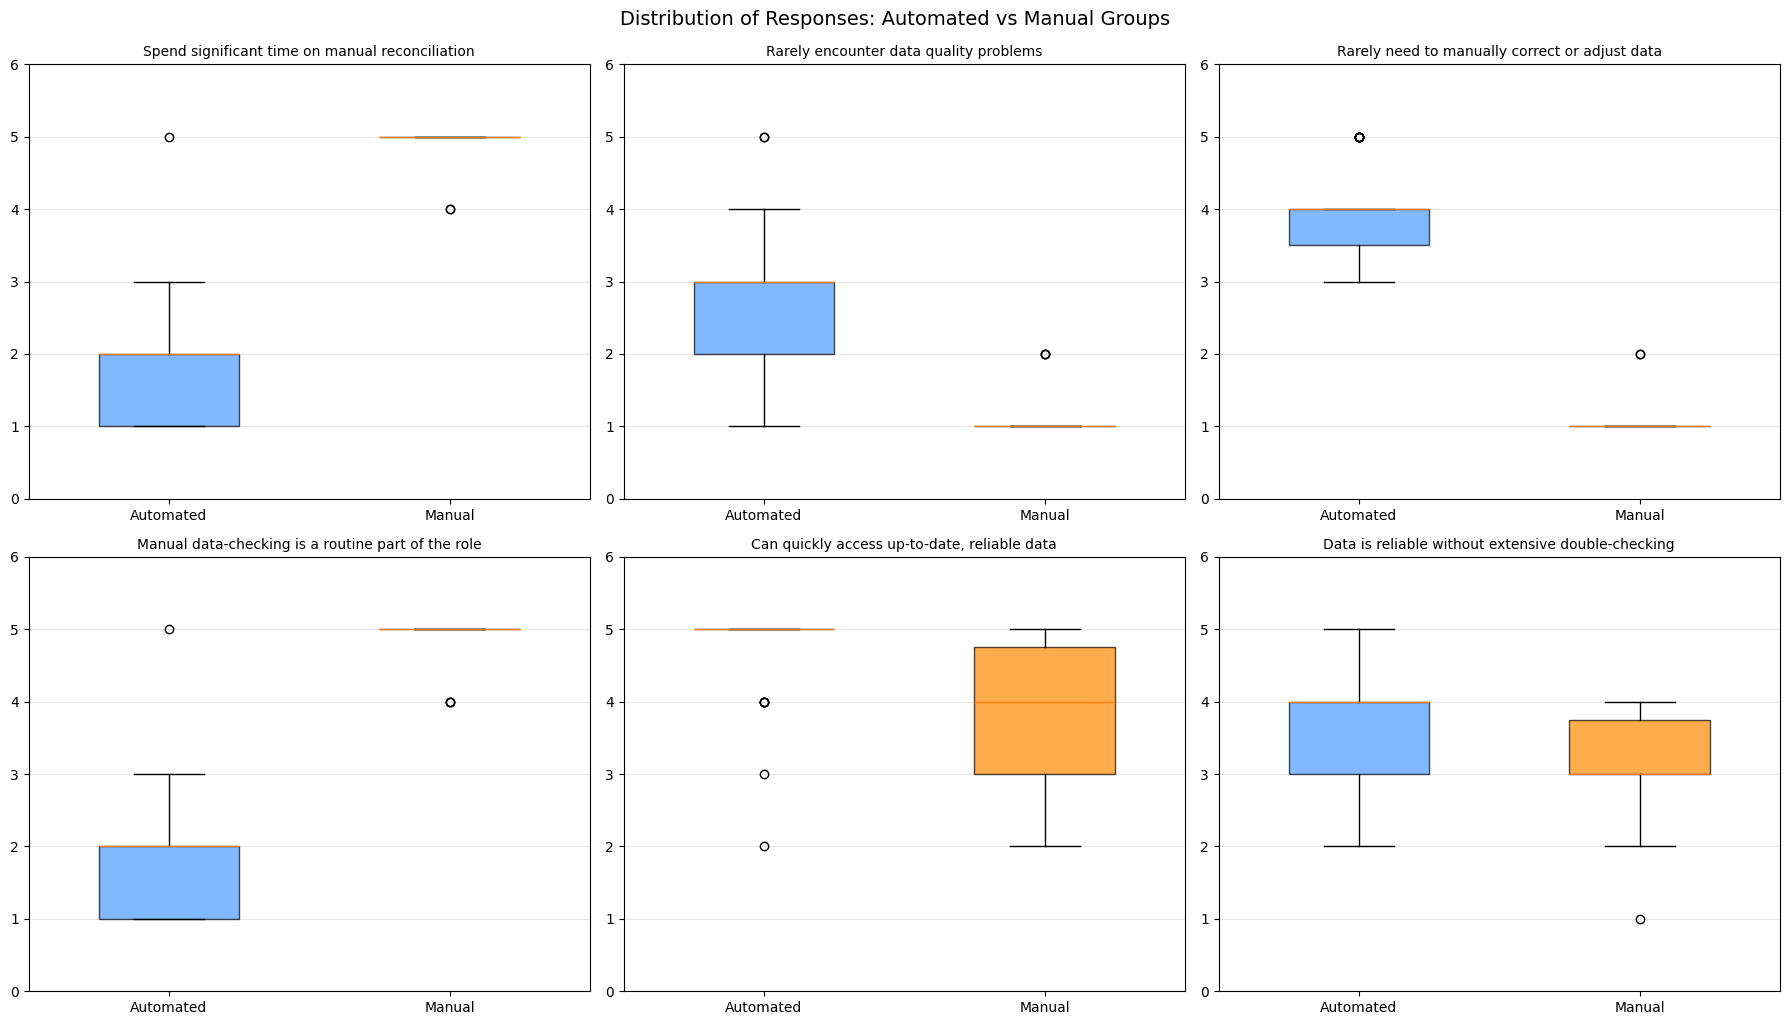

In [0]:
import matplotlib.pyplot as plt

top_items = summary_df[summary_df["Significant (p<0.05)"] == "Yes"].head(6)["Item"].tolist()
item_map_inv = {v: k for k, v in item_map.items()}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, item_label in zip(axes, top_items):
    col = item_map_inv[item_label]
    data_to_plot = [auto[col].dropna(), manual[col].dropna()]
    bp = ax.boxplot(data_to_plot, labels=["Automated", "Manual"], patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], ["#4C9AFF", "#FF8B00"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(item_label, fontsize=10)
    ax.set_ylim(0, 6)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.suptitle("Distribution of Responses: Automated vs Manual Groups", fontsize=14, y=1.02)
plt.show()

## Step 10: Consolidated Findings for Chapter 4

The analysis conducted in Steps 1 to 9 is summarised below:

1. Sample: 65 valid responses were retained after screening (43 automated-pipeline
   professionals, 22 manual/legacy professionals). This exceeds the minimum target of 40 (20 per
   group) and the total fully-powered target of 50 established in Section 3.7 via power
   analysis, although the manual/legacy group falls slightly short of the fully-powered
   per-group target of 25.

2. Normality: The Shapiro-Wilk test confirms that 10 of the 12 items depart significantly from
   normality (p < 0.05), supporting the use of the non-parametric Mann-Whitney U test specified
   in Section 3.9. The two items that did not depart from normality showed zero variance across
   all responses and are addressed separately in point 4 below.

3. Hypothesis test outcome: 6 of the 12 items show a statistically significant difference
   between groups (p < 0.05), all with medium-to-large effect sizes (r ranging from -0.382 to
   0.975), consistently favouring the automated-pipeline group. These items relate to time spent
   on manual reconciliation, frequency of manual data-checking, need for manual correction,
   frequency of data quality problems, speed of data access, and reliability without extensive
   double-checking. The remaining non-significant items also lean in the direction of the
   automated group, and none of the twelve items favour the manual/legacy group. This provides
   empirical support for H1 and, correspondingly, for the rejection of H0.

4. Notable exception: Two confidence/trust-related items ("confident in reports/dashboards used
   for decisions" and "trust the accuracy of numbers in team reports") show zero variance across
   both groups, with every respondent selecting the maximum scale value (mean = 5.00, SD = 0.00
   in both groups), yielding p = 1.0000. This indicates a ceiling effect in subjective confidence
   that appears independent of the objective efficiency differences observed on the other ten
   items, and is reported here rather than omitted, consistent with the requirement for
   methodological transparency set out in the dissertation guide.

These findings, together with the technical pipeline findings from the Bronze-to-Silver and
Silver-to-Gold notebooks and the Power BI visualisations built on the Gold layer, form the
empirical basis for Chapter 4 of the dissertation.